In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import json
import arviz as az

In [2]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Ontogeny/T1_varyinflux.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

print(df_ont.head(10))

                              mouse  age.at.S1K      MZ_Ki67+  \
0    Samples_Spleen_002_d11_017.fcs          11   2750.222222   
1    Samples_Spleen_003_d11_018.fcs          11   1000.000000   
2    Samples_Spleen_004_d11_019.fcs          11   2849.805310   
3    Samples_Spleen_005_d11_020.fcs          11    269.856985   
4    Samples_Spleen_006_d14_021.fcs          14  56055.042735   
5    Samples_Spleen_007_d14_022.fcs          14  27720.194489   
6    Samples_Spleen_008_d14_023.fcs          14    753.412564   
7    Samples_Spleen_009_d14_024.fcs          14  32426.329114   
8    Samples_Spleen_010_d14_025.fcs          14  45418.865979   
9  X20181210_Spleen_d18_002_055.fcs          18   3931.767372   

   T1 AA4.1+_Ki67+       MZ_total  T1 AA4.1+_total  frac_MZ_Ki67+  \
0     2.766195e+06   12058.666667     4.145272e+06       0.228070   
1     1.983750e+06    7450.000000     3.223400e+06       0.134228   
2     2.222848e+06   18873.238938     3.302817e+06       0.150997   
3     2.

array([<Axes: title={'center': 'r_phi'}>, <Axes: title={'center': 'phi'}>,
       <Axes: title={'center': 'rho'}>, <Axes: title={'center': 'delta'}>],
      dtype=object)

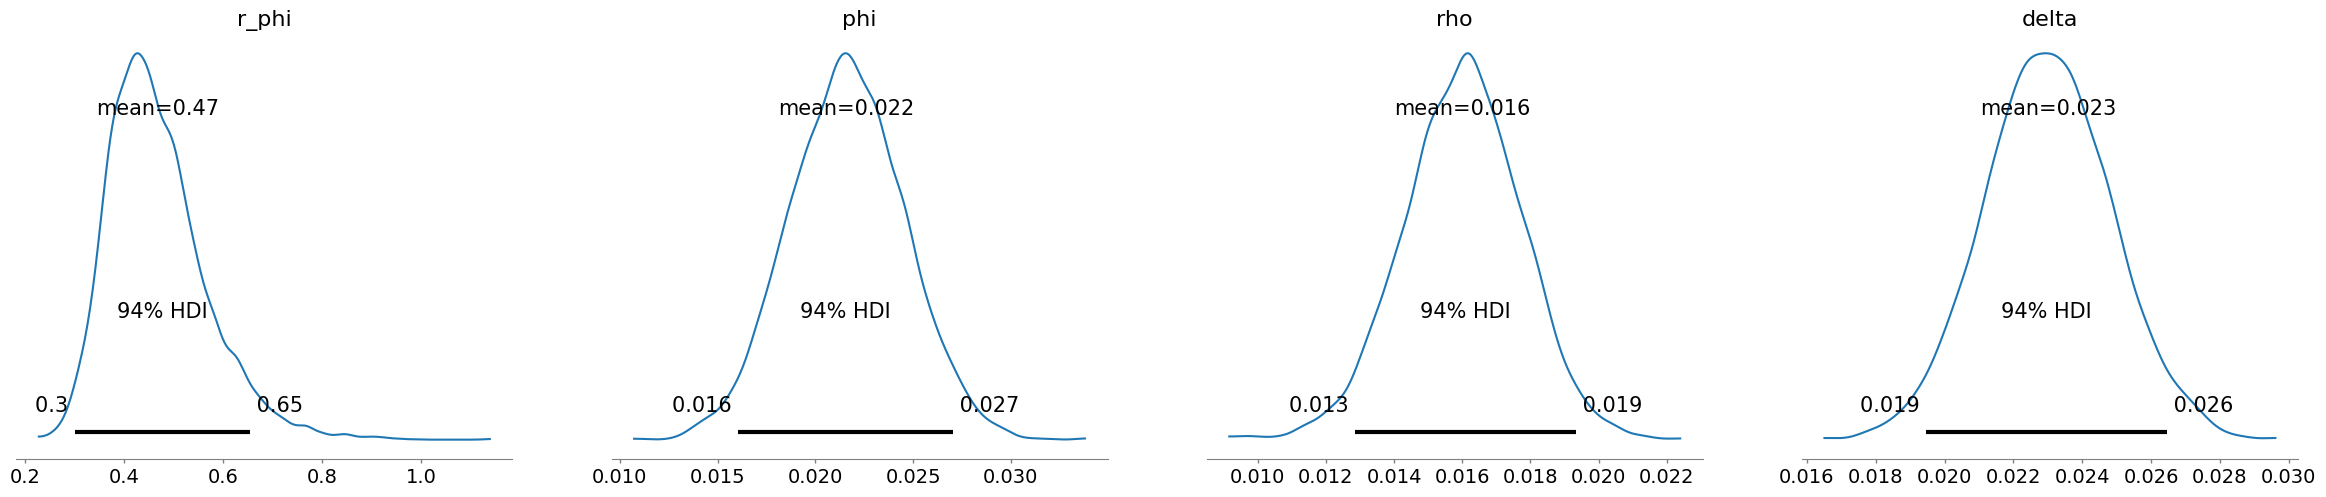

In [4]:
az.plot_posterior(data_neutral, var_names=['r_phi', 'phi', 'rho', 'delta'], kind='kde')



/tmp/ipykernel_808559/3106346908.py:23: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


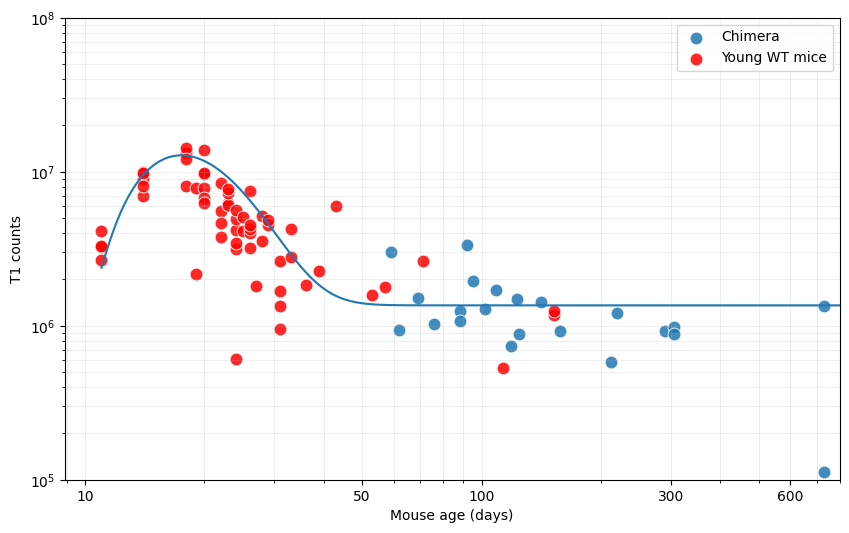

In [5]:
def P(t):
    # theta_0 = np.exp(14.15)
    # nu = 0.27
    # n = 2
    # # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    # return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    

# Plot T1 AA4.1 counts

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=85, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=85, color = 'Red',label='Young WT mice', legend=False)
plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)))
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('T1 counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [6]:
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi(t) * P(t) + rho* M - delta * M
    return np.array(dMdt) 


# Define the parameters as array
# lamda = np.mean(data_neutral.delta) - np.mean(data_neutral.rho)
rho = data_neutral.rho
delta = data_neutral.delta
print("rphi", np.mean(data_neutral.r_d))


#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi_values = data_neutral.stan_variable('phi')  # Extract 'phi' values from CmdStanMCMC object
r_phi_values = data_neutral.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object

sol = np.zeros((len(phi_values), len(t_ev)))
for i in range(len(phi_values)):
    def phi(t):
        return phi_values[i] / (1 + np.exp(-r_phi_values[i] * (t - 30)))
    
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho[i], delta[i], P))
    sol[i, :] = result.y[0]

print(sol.shape)




AttributeError: Unknown variable name: r_d
Available variables are sigma, phi, r_phi, delta, rho, t0, y1, k_hat, totalMz_mean, MZ_counts_mean, parms, k_hat_pred1, MZ_counts_pred, influx_rate, log_lik_Mz, residuals_Mz

/tmp/ipykernel_1776558/2780013182.py:11: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


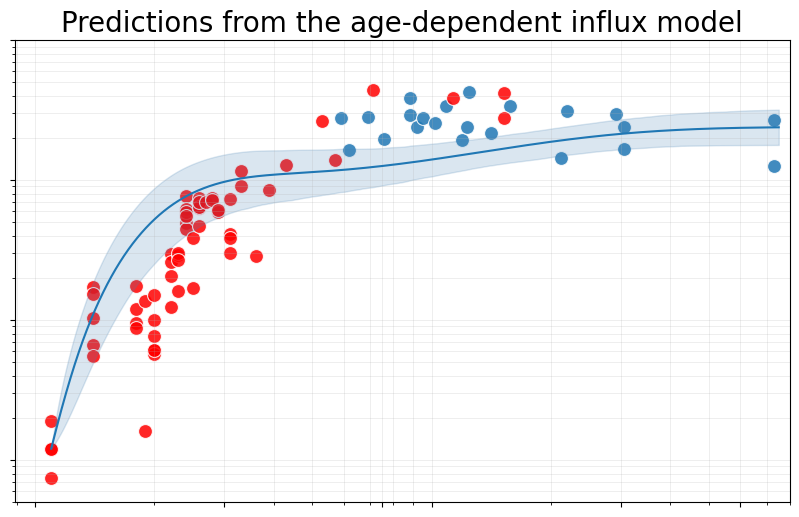

In [ ]:
# Plot the Mz counts

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(t_ev, np.mean(sol, axis=0))
plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [])
plt.yticks([1e4, 1e5, 1e6, 1e7], [])
plt.title('Predictions from the age-dependent influx model', fontsize=20)
plt.xlabel('')
plt.ylabel('')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.legend()
plt.show()



In [ ]:
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = 23
    phi = 0.015
    # phi_var =  ((phi - 0.002) / (1 + np.exp(-(r_phi) * (t-21)))) +0.002
    phi_var = (phi - 0.0015) / (1 + (r_phi / t)**5) + 0.0015
    return phi_var

# Define the ODE function
def ode_function(t, M):
    dMdt = phi(t) * P(t) + rho * M - delta * M
    return np.array(dMdt)

# Define the parameters for T2 Precursor
rho = np.mean(data_neutral.rho)
delta = np.mean(data_neutral.delta)

#Initial conditions at time t =40
M0 = [12058]


t_ev = np.arange(11, 750, 0.001)


sol_1 = solve_ivp(ode_function, [11,750], M0, t_eval=t_ev)
print(sol_1.y)


[[  12058.           12062.25227818   12066.50828244 ... 2327878.33912621
  2327878.35999051 2327878.38085471]]


/tmp/ipykernel_1776558/3026728951.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


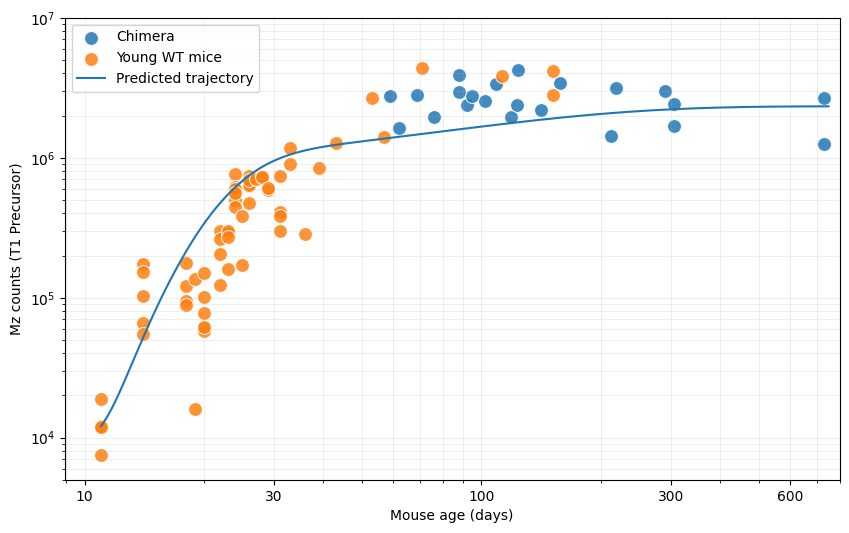

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


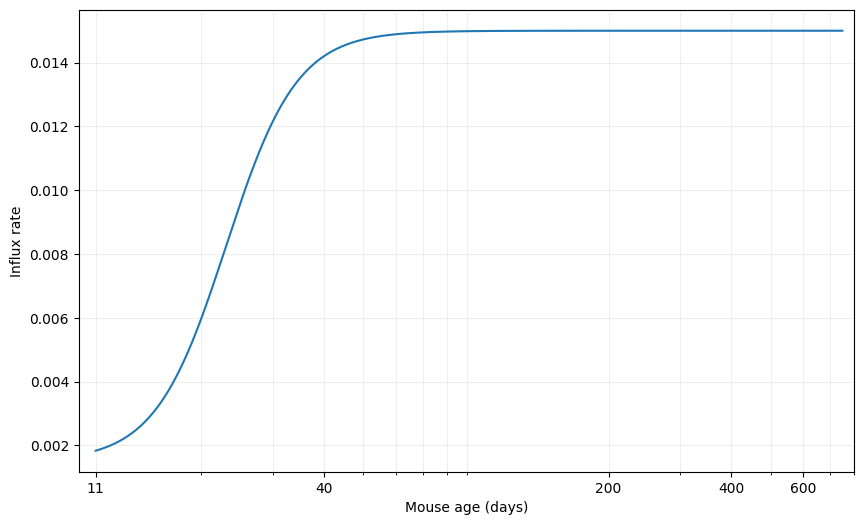

In [ ]:
#Daily Influx from T1 TO Mz
# Plot phi(t)

fig = plt.figure(figsize=(10, 6))
plt.plot(t_ev, phi(t_ev))
plt.xscale('log')
# plt.yscale('log')
plt.xlim(10, 800)
# plt.ylim(0, 0.02)
plt.xticks([11, 40, 200, 400, 600], [11, 40, 200, 400, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Influx rate')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()

